# Kanapy – Script to generate abaqus input files with boundary conditions.
Generate a representatative volume element (RVE) for a synthetic microstructure and export geometry as Abaqus INP file. The boundary conditions are stress or strain based and given to include periodic or non periodic boundary conditions. 

Author: Alexander Hartmaier, ICAMS / Ruhr-University Bochum, Germany 

Copyright © by the author, August 2025

### 1. Import required libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import kanapy as knpy
if int(knpy.__version__[0]) < 6 or int(knpy.__version__[2]) < 1:
    raise ModuleNotFoundError(f'Kanapy version 6.1. or higher is required. Current version is {knpy.__version__}. Please update Kanapy')
print(f'Kanapy version {knpy.__version__}')

Kanapy version 6.5.4


### 2. Read microstructure from RVE file

Import  microstructure generated from the example "generate_rve.ipynb" and instatiate microstructure object `ms` from it and generate 3D plot of microstructure. The export procedures to Abaqus input (.inp) files can be conducted on any microstructure object, independent of how it has been generated.

Creating an RVE from voxel input
  RVE characteristics:
    RVE side lengths (X, Y, Z) = (50, 50, 50) (um)
    Number of voxels (X, Y, Z) = (30, 30, 30)
    Voxel resolution (X, Y, Z) = [1.6667 1.6667 1.6667](um)
    Total number of voxels     = 27000


Considered phases (volume fraction): 
0: iron_fcc (100.0%)


    Generating voxels inside RVE

 Voxel structure imported.



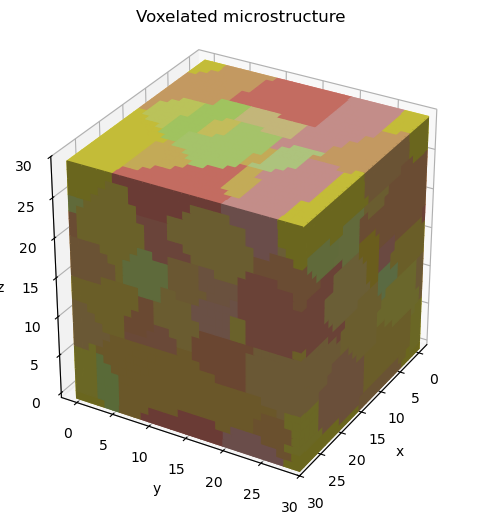

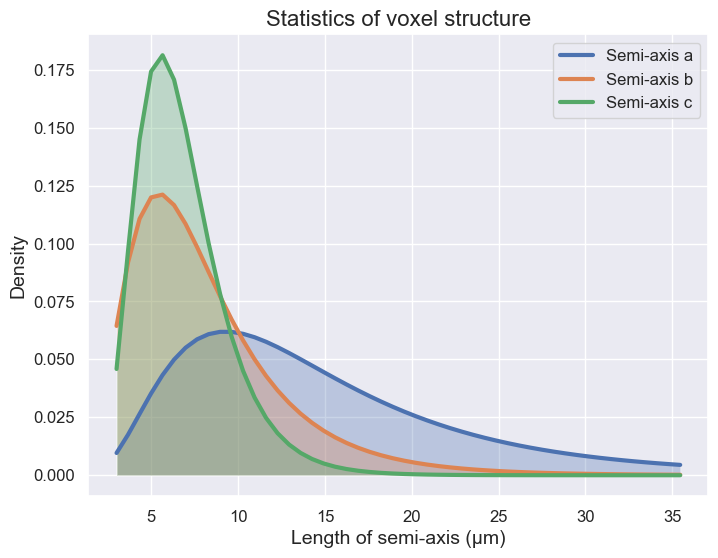


Statistical microstructure parameters of RVE
--------------------------------------------
Type	| a (µm) 	| b (µm) 	| c (µm) 	| std.dev	| rot.axis	| asp.ratio	| std.dev	| equ.dia. (µm)	| std.dev
Voxels	|  13.057	|  7.164	|  6.358	|  0.4939	|     0   	|  1.931	|  0.6003	|     16.843 	|  0.4674


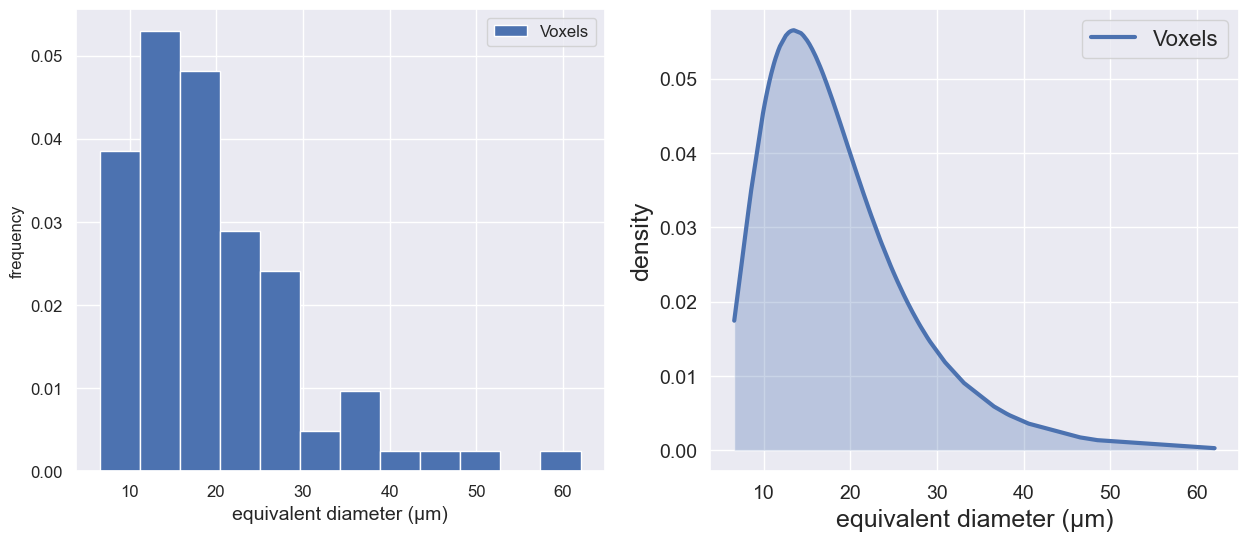

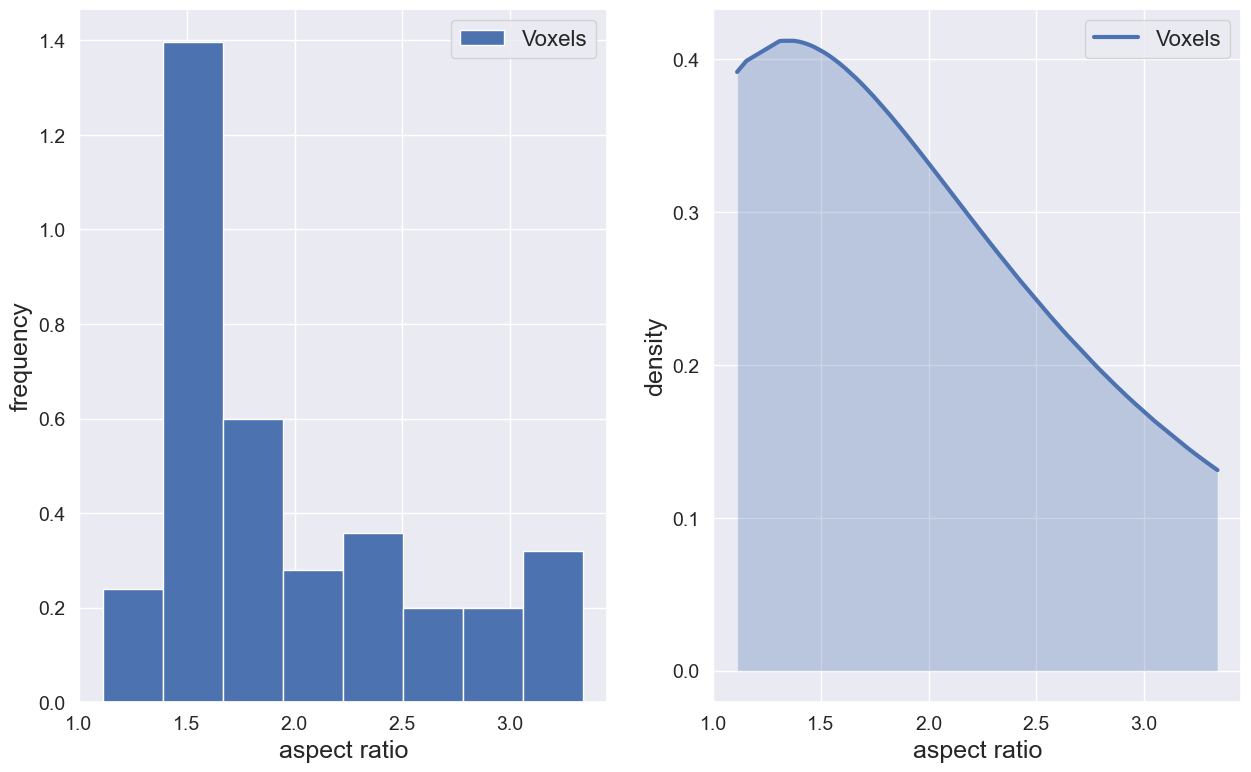

In [2]:
ms = knpy.import_voxels('demo_voxels.json')
ms.plot_voxels(ori=True)
ms.plot_stats(show_all=True)

ialloy = 4  # specify material number in ICAMS CP-UMAT for asutenite (iron_fcc)

### 3. Generating the Abaqus input file with boundary conditions. 

The application of boundary conditions in Kanapy's `export2abaqus` function is handled through the `ms.write_abq` method, where loads are set using the `value` parameter as a list of six elements `[XX, YY, ZZ, XY, XZ, YZ]`. Stress loads are defined with numerical values, like putting a number in one direction and zeros elsewhere, while strain loads use a percentage value (for example 0.1 for 10%) with `'*'` for the other directions, such as percentage value in one spot and asterisks for the rest.we Periodic boundary conditions are applied by setting `periodicBC=True`, which links opposite faces with `*Equation` cards, while non-periodic conditions are set with `periodicBC=False`, fixing one side and loading the other. Stress is applied as distributed load `*Dsload` on the respective face for non-periodic cases. While for Periodic ones a concentrated load (`*Cload`) for periodic ones, and true strain is converted into displacement using a formula that adjusts based on the RVE's size. The direction and amount can be tweaked in the `value` list, and the resulting `.inp` files are created for further use. These files include written step definitions, such as a nonlinear geometry step (`*Step, name=Loading, nlgeom=YES, inc=500000`) with a static analysis using an initial time increment of 0.001, a maximum increment of 1.0, a minimum increment of 1e-6, and a total time of 0.02, along with load applications, and output requests that encompass field outputs for node data (e.g., `CF, COORD, RF, U`) and element data (e.g., `LE, MISES, PE, PEEQ, S, SDEG`) with directions, plus history outputs with preselected variables, configured to allow direct submission for analysis in Abaqus. Below are few use cases on how the boundary conditions are applied. 

#### 3.1 Non Periodic Boundary condition (Stress)
The following boundary condition applies a stress of 150 MPa in the x-direction. 

In [3]:
pbc_mechanic = False  # indicate if mechanical periodic boundary conditions (pbc) should be applied
ptag = 'pbc' if pbc_mechanic else 'non-pbc'
ftrunc = f'demo_vox{ms.mesh.nvox}_gr{ms.Ngr}_{ptag}_stress'
bc = {
    "apply_bc": True,
    "periodic_bc": pbc_mechanic,
    "type_bc": "stress",
    "components_bc": [150, 0, 0, 0, 0, 0]  # # Components: 11, 22, 33, 12, 13, 23; float: value of stress BC, 0: free BC
}
fname = ms.write_abq(
    nodes='v',
    file=ftrunc+'_geom.inp',
    boundary_conditions=bc,
    units='mm',
    ialloy=ialloy,
    crystal_plasticity=True)
ms.write_abq_ori(file=ftrunc+'_mat.inp', ialloy=ialloy)

Control mode: stress | Boundary condition type: False | Loading mode: uni-axial | Applied component: x | Magnitude value: 150.0

Writing RVE as ABAQUS file "./demo_vox27000_gr90_non-pbc_stress_geom.inp"
Using brick element type C3D8.
---->DONE! 



#### 3.2 Non Periodic Boundary condition (Strain)
The following boundary condition applies a strain of 10% in the y-direction. 

In [4]:
pbc_mechanic = False  # indicate if mechanical periodic boundary conditions (pbc) should be applied
ptag = 'pbc' if pbc_mechanic else 'non-pbc'
ftrunc = f'demo_vox{ms.mesh.nvox}_gr{ms.Ngr}_{ptag}_strain'
bc = {
    "apply_bc": True,
    "periodic_bc": pbc_mechanic,
    "type_bc": "strain",
    "components_bc": [0.2, '*', '*', '*', '*', '*']  # Components: 11, 22, 33, 12, 13, 23; float: value of strain BC, '*': free BC
}
fname = ms.write_abq(
    nodes='v',
    file=ftrunc+'_geom.inp',
    boundary_conditions=bc,
    units='mm',
    ialloy=ialloy,
    crystal_plasticity=True)
ms.write_abq_ori(file=ftrunc+'_mat.inp', ialloy=ialloy)

Control mode: strain | Boundary condition type: False | Loading mode: uni-axial | Applied component: x | Magnitude value: 0.2

Writing RVE as ABAQUS file "./demo_vox27000_gr90_non-pbc_strain_geom.inp"
Using brick element type C3D8.
Applied component: x, Stretch ratio λ: 0.200000, Log strain ε (per rule): 0.200000, Edge length: 0.050000 mm, Displacement: 0.011070 mm
---->DONE! 



#### 3.3 Periodic Boundary condition (Stress)
The following boundary condition applies a stress of 150 MPa in the z-direction. 

In [5]:
pbc_mechanic = True  # indicate if mechanical periodic boundary conditions (pbc) should be applied
if pbc_mechanic:
    assert ms.rve.periodic  # periodic mechanical boundary conditions can only be used for periodic RVEs
ptag = 'pbc' if pbc_mechanic else 'non-pbc'
ftrunc = f'demo_vox{ms.mesh.nvox}_gr{ms.Ngr}_{ptag}_stress'
bc = {
    "apply_bc": True,
    "periodic_bc": pbc_mechanic,
    "type_bc": "stress",
    "components_bc": [150, 0, 0, 0, 0, 0]  # Components: 11, 22, 33, 12, 13, 23; float: value of stress BC, 0: free BC
}
fname = ms.write_abq(
    nodes='v',
    file=ftrunc+'_geom.inp',
    boundary_conditions=bc,
    units='mm',
    ialloy=4,
    crystal_plasticity=True)

Control mode: stress | Boundary condition type: True | Loading mode: uni-axial | Applied component: x | Magnitude value: 150.0

Writing RVE as ABAQUS file "./demo_vox27000_gr90_pbc_stress_geom.inp"
Using brick element type C3D8.
---->DONE! 



#### 3.4 Periodic Boundary condition (Strain)
The following boundary condition applies a strain of 5% in the z-direction. 

In [6]:
pbc_mechanic = True  # indicate if mechanical periodic boundary conditions (pbc) should be applied
if pbc_mechanic:
    assert ms.rve.periodic  # periodic mechanical boundary conditions can only be used for periodic RVEs
ptag = 'pbc' if pbc_mechanic else 'non-pbc'
ftrunc = f'demo_vox{ms.mesh.nvox}_gr{ms.Ngr}_{ptag}_strain'
assert ms.rve.periodic  # periodic mechanical boundary conditions can only be used for periodic RVEs
bc = {
    "apply_bc": True,
    "periodic_bc": pbc_mechanic,
    "type_bc": "strain",
    "components_bc": [1.2, '*', '*', '*', '*', '*']  # float: value of BC, '*': free BC, 
}
fname = ms.write_abq(
    nodes='v',
    file=ftrunc+'_geom.inp',
    boundary_conditions=bc,
    units='mm',
    ialloy=4,
    crystal_plasticity=True)

Control mode: strain | Boundary condition type: True | Loading mode: uni-axial | Applied component: x | Magnitude value: 1.2

Writing RVE as ABAQUS file "./demo_vox27000_gr90_pbc_strain_geom.inp"
Using brick element type C3D8.
---->DONE! 

